In [26]:
#Load and Ininitalize the Supply chain ridk dataset
import os 

print(os.getcwd())
print(os.listdir())


C:\Users\anura\risk_analysis_python
['.ipynb_checkpoints', 'Exploratory_analysis.ipynb', 'global_supply_chain_risk_2026.csv']


In [27]:
#Initial dataset Inspection
import pandas as pd
import numpy as np

supply_data = pd.read_csv(r"C:\Users\anura\risk_analysis_python\global_supply_chain_risk_2026.csv")

print(supply_data.shape)
print()
print(supply_data.columns)
print()
print(supply_data.info())
print()
print(supply_data.describe())
print()
print(supply_data.isna().sum())

(5000, 14)

Index(['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port',
       'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT',
       'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index

In [28]:
#Duplicate Records and Shipment ID validation

print(supply_data.duplicated().sum())
print()
print(supply_data["Shipment_ID"].nunique())

0

5000


In [29]:
#Date Conversion and Data type validation

print(supply_data.info())

supply_data["Date"] = pd.to_datetime(supply_data["Date"])

print()
print(supply_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [30]:
#Date range, missing values etc consistency check


supply_data["Date"] = pd.to_datetime(supply_data["Date"], errors = "coerce")
min_date = supply_data["Date"].min()
max_date = supply_data["Date"].max()

print("Minimum date:",  min_date)
print("Maximum date:", max_date)
print("Null values: ", supply_data["Date"].isna().sum())
print("Duplicate values:", supply_data["Date"].duplicated().sum())
print("Year frequency:", supply_data["Date"].dt.year.value_counts().sort_index())

supply_data = supply_data.sort_values("Date")

supply_data["difference"] = supply_data["Date"].diff()
print()
print(supply_data["difference"].describe())

Minimum date: 2024-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00
Null values:  0
Duplicate values: 4269
Year frequency: Date
2024    2455
2025    2545
Name: count, dtype: int64

count                      4999
mean     0 days 03:30:16.923384
std      0 days 08:28:33.958811
min             0 days 00:00:00
25%             0 days 00:00:00
50%             0 days 00:00:00
75%             0 days 00:00:00
max             1 days 00:00:00
Name: difference, dtype: object


In [31]:
#Getting info about the unique values

print("Unique frequency of Origin Port:", supply_data["Origin_Port"].nunique())
print("Unique values of Origin Port:", supply_data["Origin_Port"].unique())
print()
print("Unique frequency of Destination Port:", supply_data["Destination_Port"].nunique())
print("Unique values of Destination Port:", supply_data["Destination_Port"].unique())
print()
print("Unique frequency of Transport Mode:", supply_data["Transport_Mode"].nunique())
print("Unique values of Transport Mode:", supply_data["Transport_Mode"].unique())
print()
print("Unique frequency of Product Category:", supply_data["Product_Category"].nunique())
print("Unique values of Product Category:", supply_data["Product_Category"].unique())
print()
print("Unique frequency of Weather Condition:", supply_data["Weather_Condition"].nunique())
print("Unique values of Weather Condition:", supply_data["Weather_Condition"].unique())

Unique frequency of Origin Port: 8
Unique values of Origin Port: <ArrowStringArray>
[   'Shanghai',     'Hamburg',   'Rotterdam', 'Los Angeles',       'Dubai',
     'Antwerp',       'Busan',   'Singapore']
Length: 8, dtype: str

Unique frequency of Destination Port: 9
Unique values of Destination Port: <ArrowStringArray>
['Los Angeles',     'Antwerp',       'Dubai',   'Singapore',   'Rotterdam',
     'Hamburg',   'Marseille',       'Busan',    'Shanghai']
Length: 9, dtype: str

Unique frequency of Transport Mode: 4
Unique values of Transport Mode: <ArrowStringArray>
['Rail', 'Sea', 'Air', 'Road']
Length: 4, dtype: str

Unique frequency of Product Category: 5
Unique values of Product Category: <ArrowStringArray>
['Electronics', 'Pharmaceuticals', 'Perishables', 'Textiles', 'Automotive']
Length: 5, dtype: str

Unique frequency of Weather Condition: 5
Unique values of Weather Condition: <ArrowStringArray>
['Hurricane', 'Storm', 'Fog', 'Rain', 'Clear']
Length: 5, dtype: str


In [32]:
#Checking for variable range and outliers

columns = ["Distance_km", "Weight_MT", "Fuel_Price_Index", "Geopolitical_Risk_Score", "Carrier_Reliability_Score", "Lead_Time_Days", "Disruption_Occurred"]

for col in columns:
    Q1 = supply_data[col].quantile(0.25)
    Q2 = supply_data[col].quantile(0.75)
    IQR = Q2 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q2 + 1.5 * IQR

    abnormal = ((supply_data[col] < lower) | (supply_data[col] > upper)).sum()
    
    print("Minimum value of", col, ":", supply_data[col].min())
    print("Maximium value of", col, ":", supply_data[col].max())
    print("Abnormal value of", col, ":", abnormal)
    print()

Minimum value of Distance_km : 500.17
Maximium value of Distance_km : 14995.91
Abnormal value of Distance_km : 0

Minimum value of Weight_MT : 1.03
Maximium value of Weight_MT : 499.75
Abnormal value of Weight_MT : 0

Minimum value of Fuel_Price_Index : 1.2
Maximium value of Fuel_Price_Index : 4.5
Abnormal value of Fuel_Price_Index : 0

Minimum value of Geopolitical_Risk_Score : 0.0
Maximium value of Geopolitical_Risk_Score : 10.0
Abnormal value of Geopolitical_Risk_Score : 0

Minimum value of Carrier_Reliability_Score : 0.5
Maximium value of Carrier_Reliability_Score : 1.0
Abnormal value of Carrier_Reliability_Score : 0

Minimum value of Lead_Time_Days : 0.5
Maximium value of Lead_Time_Days : 236.39
Abnormal value of Lead_Time_Days : 518

Minimum value of Disruption_Occurred : 0
Maximium value of Disruption_Occurred : 1
Abnormal value of Disruption_Occurred : 0



In [116]:
#Found abnormal values in Lead time days so investigating furthur
min_lead = supply_data["Lead_Time_Days"].min()
max_lead = supply_data["Lead_Time_Days"].max()
median_lead = supply_data["Lead_Time_Days"].median()

Q1_lead = supply_data["Lead_Time_Days"].quantile(0.25)
Q3_lead = supply_data["Lead_Time_Days"].quantile(0.75)
IQR_lead = Q3_lead - Q1_lead

lower_lead = Q1_lead - 1.5 * IQR_lead
upper_lead = Q3_lead + 1.5 * IQR_lead

Leadtimedelays_above_upper = (supply_data.loc[supply_data["Lead_Time_Days"] > upper_lead, "Lead_Time_Days"]).count()

disruption_below_upper = (supply_data.loc[(supply_data["Lead_Time_Days"] < upper_lead) & (supply_data["Disruption_Occurred"] == 1), 
                                                    ["Lead_Time_Days"]]).count()

disruption_above_upper = (supply_data.loc[(supply_data["Lead_Time_Days"] > upper_lead) & (supply_data["Disruption_Occurred"] == 1), 
                                                    ["Lead_Time_Days"]]).count()

disruption_data = supply_data.loc[(supply_data["Lead_Time_Days"] > upper_lead) & (supply_data["Disruption_Occurred"] == 1), 
                    ["Distance_km", "Weight_MT", "Fuel_Price_Index","Geopolitical_Risk_Score", "Weather_Condition", "Carrier_Reliability_Score","Transport_Mode"]]

weather_transport_contribution_disruption = disruption_data.loc[:,["Weather_Condition", "Transport_Mode"]].value_counts()


print("minimum leadtime:", min_lead, "maximum leadtime:", max_lead, "median: ", median_lead, "Q1:", Q1_lead, "Q3:", Q3_lead,"IQR:", IQR_lead,"lower:", lower_lead,"upper:", upper_lead)
print()
print("Count of values above upper:", Leadtimedelays_above_upper)
print()
print("Count of values below the outlier value and disruption occured: ", disruption_below_upper)
print()
print("Count of values above the outlier value and disruption occured: ",disruption_above_upper)
print()
print(disruption_data.describe())
print()
print(weather_transport_contribution_disruption)



minimum leadtime: 0.5 maximum leadtime: 236.39 median:  8.245000000000001 Q1: 2.11 Q3: 21.2075 IQR: 19.0975 lower: -26.536250000000003 upper: 49.853750000000005

Count of values above upper: 518

Count of values below the outlier value and disruption occured:  Lead_Time_Days    2562
dtype: int64

Count of values above the outlier value and disruption occured:  Lead_Time_Days    501
dtype: int64

        Distance_km   Weight_MT  Fuel_Price_Index  Geopolitical_Risk_Score  \
count    501.000000  501.000000        501.000000               501.000000   
mean   10643.919222  243.051058          2.825349                 5.485030   
std     2772.457301  141.327105          0.941691                 2.787823   
min     3484.020000    1.120000          1.200000                 0.000000   
25%     8912.500000  120.370000          1.990000                 3.400000   
50%    10863.420000  236.120000          2.790000                 5.600000   
75%    12833.440000  365.530000          3.660000      

In [119]:
# Lead Time and Weather Impact on Supply Chain Disruptions
low_range_data = supply_data.loc[(supply_data["Lead_Time_Days"] >= min_lead) & (supply_data["Lead_Time_Days"] < Q1_lead), ["Weather_Condition","Disruption_Occurred"]]
mid_low_range_data = supply_data.loc[(supply_data["Lead_Time_Days"] >= Q1_lead ) & (supply_data["Lead_Time_Days"] < median_lead),["Weather_Condition","Disruption_Occurred"]]
mid_high_range_data = supply_data.loc[(supply_data["Lead_Time_Days"] >= median_lead ) & (supply_data["Lead_Time_Days"] < Q3_lead),["Weather_Condition","Disruption_Occurred"]]
high_range_data = supply_data.loc[(supply_data["Lead_Time_Days"] >= Q3_lead ) & (supply_data["Lead_Time_Days"] <= max_lead),["Weather_Condition","Disruption_Occurred"]]

low_disrup_data = low_range_data.loc[low_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name = "Low Disruption_Count")
low_disrup_data["L_Total_count"] = low_disrup_data["Weather_Condition"].map(low_range_data["Weather_Condition"].value_counts())
low_disrup_data["Low-Disruption_rate"] = round((low_disrup_data["Low Disruption_Count"]/low_disrup_data["L_Total_count"])*100,2)

midl_disrup_data = mid_low_range_data.loc[mid_low_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name = "MidL Disruption_Count")
midl_disrup_data["ML_Total_count"] = midl_disrup_data["Weather_Condition"].map(mid_low_range_data["Weather_Condition"].value_counts())
midl_disrup_data["MidL-Disruption_rate"] = round((midl_disrup_data["MidL Disruption_Count"]/midl_disrup_data["ML_Total_count"])*100,2)

midh_disrup_data = mid_high_range_data.loc[mid_high_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name = "MidH Disruption_Count")
midh_disrup_data["MH_Total_count"] = midh_disrup_data["Weather_Condition"].map(mid_high_range_data["Weather_Condition"].value_counts())
midh_disrup_data["MidH-Disruption_rate"] = round((midh_disrup_data["MidH Disruption_Count"]/midh_disrup_data["MH_Total_count"])*100,2)


high_disrup_data = high_range_data.loc[high_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name = "High Disruption Count")
high_disrup_data["H_Total_count"] = high_disrup_data["Weather_Condition"].map(high_range_data["Weather_Condition"].value_counts())
high_disrup_data["High-Disruption_rate"] = round((high_disrup_data["High Disruption Count"]/high_disrup_data["H_Total_count"])*100,2)

comb_data = low_disrup_data.merge(midl_disrup_data, on = "Weather_Condition", how= "left")
comb_data = comb_data.merge(midh_disrup_data, on = "Weather_Condition", how= "left")
comb_data = comb_data.merge(high_disrup_data, on = "Weather_Condition", how= "left")

print(len(low_range_data), len(mid_low_range_data),len(mid_high_range_data), len(high_range_data))
print()

print(comb_data)

1249 1251 1250 1250

  Weather_Condition  Low Disruption_Count  L_Total_count  Low-Disruption_rate  \
0             Clear                   125            348                35.92   
1               Fog                   159            321                49.53   
2         Hurricane                    58             58               100.00   
3              Rain                   136            318                42.77   
4             Storm                   161            204                78.92   

   MidL Disruption_Count  ML_Total_count  MidL-Disruption_rate  \
0                    116             319                 36.36   
1                    110             242                 45.45   
2                    231             231                100.00   
3                    114             280                 40.71   
4                    141             179                 78.77   

   MidH Disruption_Count  MH_Total_count  MidH-Disruption_rate  \
0                     98     

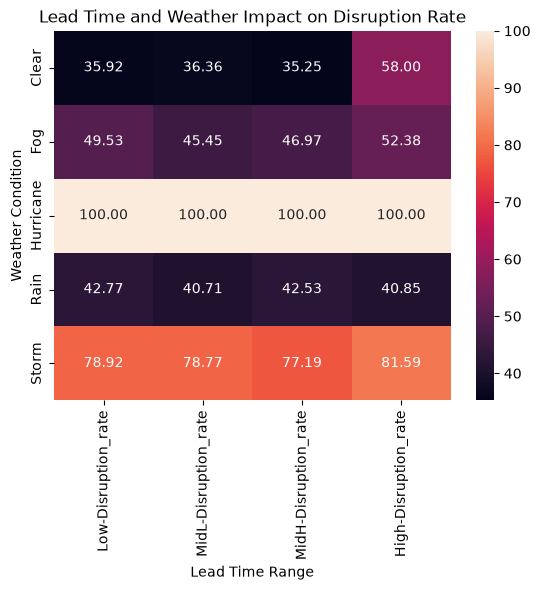

In [123]:
# Lead Time × Weather - Disruption Rate Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heatmap_data = comb_data.set_index("Weather_Condition")[["Low-Disruption_rate", "MidL-Disruption_rate", "MidH-Disruption_rate", "High-Disruption_rate"]]

sns.heatmap(heatmap_data, annot = True, fmt=".2f")

plt.title("Lead Time and Weather Impact on Disruption Rate")
plt.xlabel("Lead Time Range")
plt.ylabel("Weather Condition")
plt.show()

In [ ]:
#Investigation of Non_Disrupted Lead time outliers

non_disruption_above_upper = (supply_data.loc[(supply_data["Lead_Time_Days"] > upper_lead) & (supply_data["Disruption_Occurred"] == 0), 
                                                    ["Lead_Time_Days"]]).count()

non_disruption_data = supply_data.loc[(supply_data["Lead_Time_Days"] > upper_lead) & (supply_data["Disruption_Occurred"] == 0),
    ["Distance_km", "Weight_MT", "Fuel_Price_Index","Geopolitical_Risk_Score", "Weather_Condition", "Carrier_Reliability_Score","Transport_Mode"]]

weather_transport_contribution_nondisruption = non_disruption_data.loc[:,["Weather_Condition", "Transport_Mode"]].value_counts()
print()
print("Count of values that have no disruption eventhough they were outliers: ", non_disruption_above_upper)
print()
print(non_disruption_data.describe())
print()
print(weather_transport_contribution_nondisruption)

In [35]:
#Lead Time disruption data summary
percentage_disruption = round((disruption_above_upper.iloc[0]/ Leadtimedelays_above_upper) *100,2)
percentage_non_disruption = round((100 - percentage_disruption),2)
weather_transport_percentage_nondisruption = round((weather_transport_contribution_nondisruption/non_disruption_above_upper.iloc[0])*100,2)
weather_transport_percentage_disruption = round((weather_transport_contribution_disruption/disruption_above_upper.iloc[0])*100,2)

print(f"Percentage of disruption rate based on Lead Time delay outliers: {percentage_disruption}%")
print()
print(f"Percentage of non disruption values on Lead Time delay outliers: {percentage_non_disruption}%")
print(f"Percentage contribution of each weather condition and transport mode among non-disrupted lead-time outliers: {weather_transport_percentage_nondisruption}")
print()
print(f"Percentage contribution of each weather condition and transport mode among disrupted lead-time outliers: {weather_transport_percentage_disruption}")



Percentage of disruption rate based on Lead Time delay outliers: 96.72%

Percentage of non disruption values on Lead Time delay outliers: 3.28%
Percentage contribution of each weather condition and transport mode among non-disrupted lead-time outliers: Weather_Condition  Transport_Mode
Storm              Sea               100.0
Name: count, dtype: float64

Percentage contribution of each weather condition and transport mode among disrupted lead-time outliers: Weather_Condition  Transport_Mode
Hurricane          Sea               40.72
                   Rail              24.95
                   Road              20.36
Storm              Sea               13.97
Name: count, dtype: float64


In [36]:
#Independent factor analysis

weather_data = supply_data.groupby(["Weather_Condition", "Disruption_Occurred"]).size().reset_index(name= "Weather_Count")
weather_data["Total_Count"] = weather_data.groupby("Weather_Condition")["Weather_Count"].transform(sum)
weather_data["Disruption_rate"] = round((weather_data["Weather_Count"]/weather_data["Total_Count"])*100,2)
weather_disruption_data = weather_data[weather_data["Disruption_Occurred"] == 1][["Weather_Condition", "Disruption_rate", "Disruption_Occurred"]].reset_index() 

transport_data = supply_data.groupby(["Disruption_Occurred", "Transport_Mode"]).size().reset_index(name = "transport_count") 
transport_data["Total_count"] = transport_data.groupby("Transport_Mode")["transport_count"].transform(sum)
transport_data["Disruption_rate"] = round((transport_data["transport_count"]/transport_data["Total_count"])*100,2)
transport_disruption_data = transport_data[transport_data["Disruption_Occurred"] == 1][["Transport_Mode", "Disruption_rate", "Disruption_Occurred"]].reset_index()

product_data = supply_data.groupby(["Disruption_Occurred", "Product_Category"]).size().reset_index(name = "Product_count")
product_data["Total_count"] = product_data.groupby("Product_Category")["Product_count"].transform(sum)
product_data["Disruption_rate"] = round((product_data["Product_count"]/product_data["Total_count"])*100,2)
product_disruption_data = product_data[product_data["Disruption_Occurred"] == 1][["Product_Category", "Disruption_rate", "Disruption_Occurred"]].reset_index()

columns = ["Distance_km", "Weight_MT", "Fuel_Price_Index", "Carrier_Reliability_Score", "Geopolitical_Risk_Score"]

for cols in columns:
    min_range = supply_data[cols].min()
    max_range = supply_data[cols].max()

    avg_value = supply_data[cols].mean()
    Q1_value = supply_data[cols].quantile(0.25)
    Q3_value = supply_data[cols].quantile(0.75)
    IQR_value = Q3_value - Q1_value

    lower_value = Q1_value - 1.5 * IQR_value
    upper_value = Q3_value + 1.5 * IQR_value
    median_value = supply_data[cols].median()

    low_range_data = supply_data.loc[(supply_data[cols] >= min_range) & (supply_data[cols] < Q1_value),[cols, "Disruption_Occurred"]]
    mid_low_range_data = supply_data.loc[(supply_data[cols] >= Q1_value ) & (supply_data[cols] < median_value),[cols, "Disruption_Occurred"]]
    mid_high_range_data = supply_data.loc[(supply_data[cols] >= median_value ) & (supply_data[cols] < Q3_value), [cols, "Disruption_Occurred"]]
    high_range_data = supply_data.loc[(supply_data[cols] >= Q3_value ) & (supply_data[cols] <= max_range), [cols, "Disruption_Occurred"]]

    low_range_data = low_range_data.groupby("Disruption_Occurred").size().reset_index(name="count")
    low_range_data["Total_Count"] = low_range_data["count"].sum()
    low_range_data["Disruption_rate"] = round((low_range_data["count"]/low_range_data["Total_Count"])*100,2)

    mid_low_range_data = mid_low_range_data.groupby("Disruption_Occurred").size().reset_index(name="count")
    mid_low_range_data["Total_Count"] = mid_low_range_data["count"].sum()
    mid_low_range_data["Disruption_rate"] = round((mid_low_range_data["count"]/mid_low_range_data["Total_Count"])*100,2)

    mid_high_range_data = mid_high_range_data.groupby("Disruption_Occurred").size().reset_index(name="count")
    mid_high_range_data["Total_Count"] = mid_high_range_data["count"].sum()
    mid_high_range_data["Disruption_rate"] = round((mid_high_range_data["count"]/mid_high_range_data["Total_Count"])*100,2)

    high_range_data = high_range_data.groupby("Disruption_Occurred").size().reset_index(name="count")
    high_range_data["Total_Count"] = high_range_data["count"].sum()
    high_range_data["Disruption_rate"] = round((high_range_data["count"]/high_range_data["Total_Count"])*100,2)

    print(f"The {cols} Category data for disruptive data")
    print("Lower:")
    print(low_range_data.loc[low_range_data["Disruption_Occurred"] == 1])
    print("Mid-Low:")
    print(mid_low_range_data.loc[mid_low_range_data["Disruption_Occurred"] ==1])
    print("Mid-High:")
    print(mid_high_range_data.loc[mid_high_range_data["Disruption_Occurred"] ==1])
    print("Higher:")
    print(high_range_data.loc[high_range_data["Disruption_Occurred"] ==1])
    print()


print("The Weather condition data for the disruptive data")
print(weather_disruption_data.loc[:,["Weather_Condition", "Disruption_rate"]])
print()

print("The Transport Mode data for the disruptive data")
print(transport_disruption_data.loc[:,["Transport_Mode", "Disruption_rate"]])
print()

print("The Product Category data for the disruptive data")
print(product_disruption_data.loc[:,["Product_Category", "Disruption_rate"]])
print()

The Distance_km Category data for disruptive data
Lower:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    755         1250             60.4
Mid-Low:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    765         1250             61.2
Mid-High:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    778         1250            62.24
Higher:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    765         1250             61.2

The Weight_MT Category data for disruptive data
Lower:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    753         1250            60.24
Mid-Low:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    762         1250            60.96
Mid-High:
   Disruption_Occurred  count  Total_Count  Disruption_rate
1                    1    780         1250             62.4
H

In [37]:
## Carrier Reliability Score Range Classification
min_range = supply_data["Carrier_Reliability_Score"].min()
max_range = supply_data["Carrier_Reliability_Score"].max()

avg_value = supply_data["Carrier_Reliability_Score"].mean()
Q1_value = supply_data["Carrier_Reliability_Score"].quantile(0.25)
Q3_value = supply_data["Carrier_Reliability_Score"].quantile(0.75)
IQR_value = Q3_value - Q1_value

lower_value = Q1_value - 1.5 * IQR_value
upper_value = Q3_value + 1.5 * IQR_value
median_value = supply_data["Carrier_Reliability_Score"].median()

conditions = [(supply_data["Carrier_Reliability_Score"] >= min_range) & (supply_data["Carrier_Reliability_Score"] < Q1_value),
              (supply_data["Carrier_Reliability_Score"] >= Q1_value) & (supply_data["Carrier_Reliability_Score"] < median_value),
              (supply_data["Carrier_Reliability_Score"] >= median_value) & (supply_data["Carrier_Reliability_Score"] < Q3_value),
              (supply_data["Carrier_Reliability_Score"] >= Q3_value) & (supply_data["Carrier_Reliability_Score"] <= max_range)]

choices = ["Low", "Mid-Low", "Mid-High", "High"]

supply_data["Carrier_Reliability_Range"] = np.select(conditions,choices,default="Unknown")



     Shipment_ID       Date  Origin_Port Destination_Port Transport_Mode  \
179     SC-10179 2024-01-01     Shanghai      Los Angeles           Rail   
558     SC-10558 2024-01-01      Hamburg          Antwerp            Sea   
3654    SC-13654 2024-01-01    Rotterdam            Dubai            Air   
4195    SC-14195 2024-01-01  Los Angeles          Antwerp           Road   
3958    SC-13958 2024-01-02        Dubai      Los Angeles            Sea   

     Product_Category  Distance_km  Weight_MT  Fuel_Price_Index  \
179       Electronics      2494.05     456.70              3.60   
558   Pharmaceuticals     11449.49     138.27              2.22   
3654      Perishables       941.72     186.36              3.15   
4195      Perishables      3206.28      47.55              1.43   
3958         Textiles      1234.03     304.99              3.33   

      Geopolitical_Risk_Score Weather_Condition  Carrier_Reliability_Score  \
179                       0.8         Hurricane               

In [133]:
# Geopolitical Risk and Carrier Reliability Impact on Weather-Related Disruptions
columns = ["Geopolitical_Risk_Score","Carrier_Reliability_Score"]

for cols in columns:
    min_range = supply_data[cols].min()
    max_range = supply_data[cols].max()

    avg_value = supply_data[cols].mean()
    Q1_value = supply_data[cols].quantile(0.25)
    Q3_value = supply_data[cols].quantile(0.75)
    IQR_value = Q3_value - Q1_value

    lower_value = Q1_value - 1.5 * IQR_value
    upper_value = Q3_value + 1.5 * IQR_value
    median_value = supply_data[cols].median()

    low_range_data = supply_data.loc[(supply_data[cols] >= min_range) & (supply_data[cols] < Q1_value),[cols, "Disruption_Occurred","Weather_Condition"]]
    mid_low_range_data = supply_data.loc[(supply_data[cols] >= Q1_value ) & (supply_data[cols] < median_value),[cols, "Disruption_Occurred","Weather_Condition"]]
    mid_high_range_data = supply_data.loc[(supply_data[cols] >= median_value ) & (supply_data[cols] < Q3_value), [cols, "Disruption_Occurred","Weather_Condition"]]
    high_range_data = supply_data.loc[(supply_data[cols] >= Q3_value ) & (supply_data[cols] <= max_range), [cols, "Disruption_Occurred","Weather_Condition"]]

    risk_label = "Geo Risk" if cols == "Geopolitical_Risk_Score" else "Carrier Reliability"
    
    low_count = low_range_data.loc[low_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name="low_range_count")
    low_count["low_Total_Count"] = low_count["Weather_Condition"].map(low_range_data.groupby("Weather_Condition").size())
    low_count[f"Low {risk_label}"] = round((low_count["low_range_count"]/low_count["low_Total_Count"])*100,2)
    
    mid_low_count = mid_low_range_data.loc[mid_low_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name="mid_l_range_count")
    mid_low_count["midl_Total_Count"] = mid_low_count["Weather_Condition"].map(mid_low_range_data.groupby("Weather_Condition").size())
    mid_low_count[f"MidL {risk_label}"] = round((mid_low_count["mid_l_range_count"]/mid_low_count["midl_Total_Count"])*100,2)
    
    mid_high_count = mid_high_range_data.loc[mid_high_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name="mid_h_range_count")
    mid_high_count["midh_Total_Count"] = mid_high_count["Weather_Condition"].map(mid_high_range_data.groupby("Weather_Condition").size())
    mid_high_count[f"MidH {risk_label}"] = round((mid_high_count["mid_h_range_count"]/mid_high_count["midh_Total_Count"])*100,2)
                                                 
    high_count = high_range_data.loc[high_range_data["Disruption_Occurred"] == 1].groupby("Weather_Condition").size().reset_index(name="high_range_count")
    high_count["high_Total_Count"] = high_count["Weather_Condition"].map(high_range_data.groupby("Weather_Condition").size())
    high_count[f"High {risk_label}"] = round((high_count["high_range_count"]/high_count["high_Total_Count"])*100,2)
    
    comb_data = low_count.merge(mid_low_count, on = "Weather_Condition", how= "left")
    comb_data = comb_data.merge(mid_high_count, on = "Weather_Condition", how= "left")
    comb_data = comb_data.merge(high_count, on = "Weather_Condition", how= "left")
    
    if cols == "Geopolitical_Risk_Score":
        geo_weather_data = comb_data.copy()
    else:
        carrier_weather_data = comb_data.copy()

    print("Disruption information of: ", cols, "and Weather Conditions")
    print(comb_data)
    print()        


Disruption information of:  Geopolitical_Risk_Score and Weather Conditions
  Weather_Condition  low_range_count  low_Total_Count  Low Geo Risk  \
0             Clear               47              247         19.03   
1               Fog               72              248         29.03   
2         Hurricane              234              234        100.00   
3              Rain               51              243         20.99   
4             Storm              148              247         59.92   

   mid_l_range_count  midl_Total_Count  MidL Geo Risk  mid_h_range_count  \
0                 87               247          35.22                106   
1                109               260          41.92                139   
2                257               257         100.00                256   
3                 81               215          37.67                113   
4                192               255          75.29                209   

   midh_Total_Count  MidH Geo Risk  high_

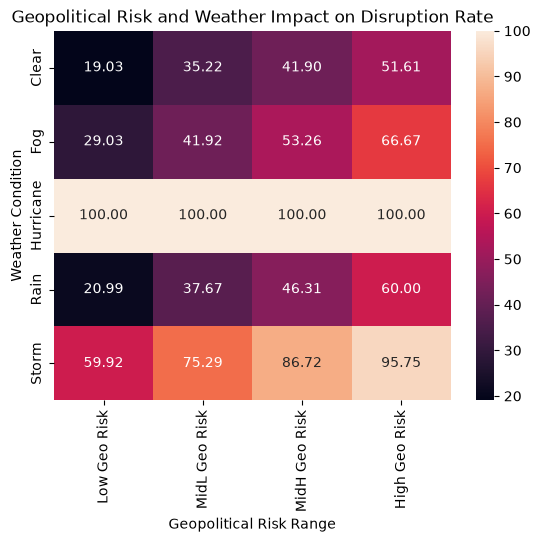

In [138]:
# Geopolitical Risk × Weather - Disruption Rate Heatmap
heatmap_data = geo_weather_data.set_index("Weather_Condition")[["Low Geo Risk", "MidL Geo Risk", "MidH Geo Risk", "High Geo Risk"]]

sns.heatmap(heatmap_data, annot = True, fmt=".2f")

plt.title("Geopolitical Risk and Weather Impact on Disruption Rate")
plt.xlabel("Geopolitical Risk Range")
plt.ylabel("Weather Condition")
plt.show()

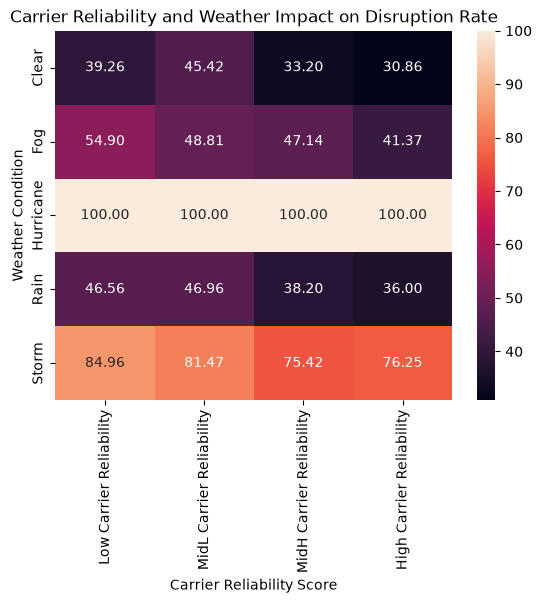

In [139]:
# Carrier Reliability × Weather - Disruption Rate Heatmap
heatmap_data = carrier_weather_data.set_index("Weather_Condition")[["Low Carrier Reliability", "MidL Carrier Reliability", "MidH Carrier Reliability", "High Carrier Reliability"]]

sns.heatmap(heatmap_data, annot = True, fmt=".2f")

plt.title("Carrier Reliability and Weather Impact on Disruption Rate")
plt.xlabel("Carrier Reliability Score")
plt.ylabel("Weather Condition")
plt.show()

In [147]:
# Geopolitical Risk × Carrier Reliability - Disruption Rate Analysis
min_range = supply_data["Geopolitical_Risk_Score"].min()
max_range = supply_data["Geopolitical_Risk_Score"].max()

avg_value = supply_data["Geopolitical_Risk_Score"].mean()
Q1_value = supply_data["Geopolitical_Risk_Score"].quantile(0.25)
Q3_value = supply_data["Geopolitical_Risk_Score"].quantile(0.75)
IQR_value = Q3_value - Q1_value

lower_value = Q1_value - 1.5 * IQR_value
upper_value = Q3_value + 1.5 * IQR_value
median_value = supply_data["Geopolitical_Risk_Score"].median()

low_range_data = supply_data.loc[(supply_data["Geopolitical_Risk_Score"] >= min_range) & (supply_data["Geopolitical_Risk_Score"] < Q1_value),["Geopolitical_Risk_Score", "Disruption_Occurred","Carrier_Reliability_Range"]]
mid_low_range_data = supply_data.loc[(supply_data["Geopolitical_Risk_Score"] >= Q1_value ) & (supply_data["Geopolitical_Risk_Score"] < median_value),["Geopolitical_Risk_Score", "Disruption_Occurred","Carrier_Reliability_Range"]]
mid_high_range_data = supply_data.loc[(supply_data["Geopolitical_Risk_Score"] >= median_value ) & (supply_data["Geopolitical_Risk_Score"] < Q3_value), ["Geopolitical_Risk_Score", "Disruption_Occurred","Carrier_Reliability_Range"]]
high_range_data = supply_data.loc[(supply_data["Geopolitical_Risk_Score"] >= Q3_value ) & (supply_data["Geopolitical_Risk_Score"] <= max_range), ["Geopolitical_Risk_Score", "Disruption_Occurred","Carrier_Reliability_Range"]]

low_count = low_range_data.loc[low_range_data["Disruption_Occurred"] == 1].groupby("Carrier_Reliability_Range").size().reset_index(name="low_range_count")
low_count["low_Total_Count"] = low_count["Carrier_Reliability_Range"].map(low_range_data.groupby("Carrier_Reliability_Range").size())
low_count["Low Geo Risk"] = round((low_count["low_range_count"]/low_count["low_Total_Count"])*100,2)
    
mid_low_count = mid_low_range_data.loc[mid_low_range_data["Disruption_Occurred"] == 1].groupby("Carrier_Reliability_Range").size().reset_index(name="mid_l_range_count")
mid_low_count["midl_Total_Count"] = mid_low_count["Carrier_Reliability_Range"].map(mid_low_range_data.groupby("Carrier_Reliability_Range").size())
mid_low_count["Mid-Low Geo Risk"] = round((mid_low_count["mid_l_range_count"]/mid_low_count["midl_Total_Count"])*100,2)
    
mid_high_count = mid_high_range_data.loc[mid_high_range_data["Disruption_Occurred"] == 1].groupby("Carrier_Reliability_Range").size().reset_index(name="mid_h_range_count")
mid_high_count["midh_Total_Count"] = mid_high_count["Carrier_Reliability_Range"].map(mid_high_range_data.groupby("Carrier_Reliability_Range").size())
mid_high_count["Mid-High Geo Risk"] = round((mid_high_count["mid_h_range_count"]/mid_high_count["midh_Total_Count"])*100,2)
                                                 
high_count = high_range_data.loc[high_range_data["Disruption_Occurred"] == 1].groupby("Carrier_Reliability_Range").size().reset_index(name="high_range_count")
high_count["high_Total_Count"] = high_count["Carrier_Reliability_Range"].map(high_range_data.groupby("Carrier_Reliability_Range").size())
high_count["High Geo Risk"] = round((high_count["high_range_count"]/high_count["high_Total_Count"])*100,2)
    
comb_data = low_count.merge(mid_low_count, on = "Carrier_Reliability_Range", how= "left")
comb_data = comb_data.merge(mid_high_count, on = "Carrier_Reliability_Range", how= "left")
comb_data = comb_data.merge(high_count, on = "Carrier_Reliability_Range", how= "left")

geo_carrier_data = comb_data.copy()

print("Disruption information of: ", "Geopolitical_Risk_Score & Carrier_Reliability_Range")
print(comb_data.loc[:,["Carrier_Reliability_Range", "Low Geo Risk","Mid-Low Geo Risk","Mid-High Geo Risk","High Geo Risk"]])


Disruption information of:  Geopolitical_Risk_Score & Carrier_Reliability_Range
  Carrier_Reliability_Range  Low Geo Risk  Mid-Low Geo Risk  \
0                      High         37.12             55.03   
1                       Low         50.00             60.88   
2                  Mid-High         44.23             56.55   
3                   Mid-Low         49.68             62.75   

   Mid-High Geo Risk  High Geo Risk  
0              59.24          70.29  
1              71.06          78.48  
2              64.07          70.61  
3              68.51          78.38  


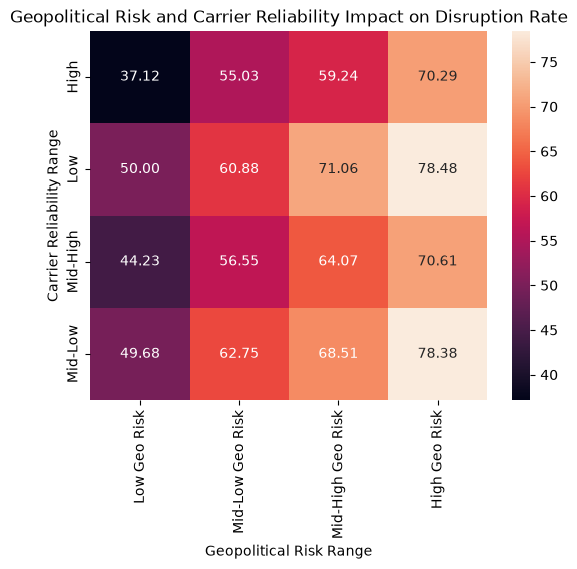

In [148]:
# Geopolitical Risk × Carrier Reliability - Disruption Rate Heatmap
heatmap_data = geo_carrier_data.set_index("Carrier_Reliability_Range")[["Low Geo Risk","Mid-Low Geo Risk","Mid-High Geo Risk","High Geo Risk"]]


sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f"
)

plt.title("Geopolitical Risk and Carrier Reliability Impact on Disruption Rate")
plt.xlabel("Geopolitical Risk Range")
plt.ylabel("Carrier Reliability Range")
plt.show()